In [51]:
import gymnasium as gym
from simulation.pendulum_env import PendulumEnv

import stable_baselines3 as sb3

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import time

In [52]:
env = PendulumEnv(time=10., freq=20, b_hi=.1)  # same as gym's pendulum params

/Users/ljn/cd_project/simulation/pendulum_model.py:16: UserWarning: This function has been marked as deprecated and will be removed in a future release.
  geom0_obj = pin.GeometryObject("base", 1, shape0, pin.SE3.Identity())  # type: ignore
/Users/ljn/cd_project/simulation/pendulum_model.py:34: UserWarning: This function has been marked as deprecated and will be removed in a future release.
  geom1_obj = pin.GeometryObject(geom1_name, joint_id, shape1, body_placement)
/Users/ljn/cd_project/simulation/pendulum_model.py:43: UserWarning: This function has been marked as deprecated and will be removed in a future release.
  geom2_obj = pin.GeometryObject(geom2_name, joint_id, shape2, shape2_placement)


In [3]:
model = sb3.SAC(
    'MlpPolicy',
    env,
    verbose=1
)
model.learn(total_timesteps=25_000)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 200       |
|    ep_rew_mean     | -1.23e+03 |
| time/              |           |
|    episodes        | 4         |
|    fps             | 119       |
|    time_elapsed    | 6         |
|    total_timesteps | 800       |
| train/             |           |
|    actor_loss      | 21        |
|    critic_loss     | 0.197     |
|    ent_coef        | 0.812     |
|    ent_coef_loss   | -0.343    |
|    learning_rate   | 0.0003    |
|    n_updates       | 699       |
----------------------------------


KeyboardInterrupt: 

In [53]:
path = 'models/sac-1pendulum.zip'
if not os.path.exists(path):
    model.save(path)
    print('Saved successfully.')
else:
    print('Already exists.')

Already exists.


In [54]:
model = sb3.SAC.load(path, env=env)

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [55]:
df = []
for run in range(100):
    obs, _ = env.reset()
    for i in range(200):
        a, _ = model.predict(obs)
        obs, r, *_ = env.step(a.astype(np.double))
        df.append({'cos': obs[0], 'sin': obs[1], 'v': obs[2], 
                   'r': r, 'run': run, 'time': env.nsteps * env.dt, 'b': env.b})
df = pd.DataFrame(df)

In [44]:
df.describe()

,cos,sin,v,r,run,time,b
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,-0.052625,-0.002763,-0.082186,-4.163937,49.500000,5.025000,0.502553
std,0.792737,0.607322,2.326609,3.616323,28.866792,2.886787,0.304519
min,-1.000000,-1.000000,-6.152883,-13.567200,0.000000,0.050000,0.000349
25%,-0.780790,-0.531181,-1.518437,-6.988637,24.750000,2.537500,0.237884
50%,-0.354899,-0.004576,-0.014735,-4.193184,49.500000,5.025000,0.475996
75%,0.999256,0.509019,1.297583,-0.005096,74.250000,7.512500,0.784425
max,1.000000,1.000000,5.975299,-0.000005,99.000000,10.000000,0.981442


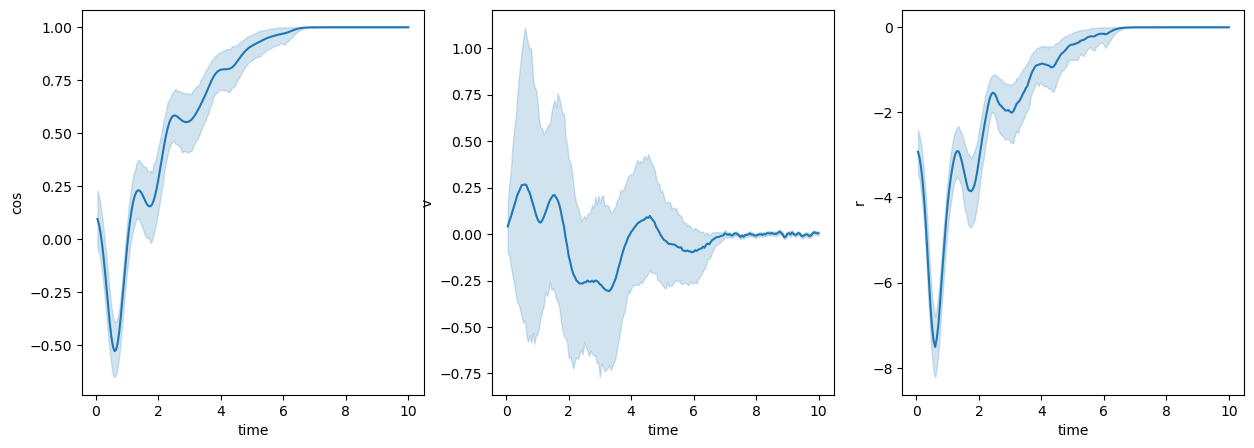

In [56]:
variables = ['cos', 'v', 'r']
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for ax, var in zip(axs, variables):
    sns.lineplot(data=df, x='time', y=var, estimator='mean', errorbar='ci', ax=ax)

In [127]:
viz = env.get_viz()
viz.viewer.jupyter_cell()

You can open the visualizer by visiting the following URL:
http://127.0.0.1:7003/static/


In [128]:
df.loc[df['b'].argmin(), 'run'], df.loc[df['b'].argmax(), 'run']

(np.int64(69), np.int64(37))

In [147]:
df_run = df[df['run'] == 37]
qs = np.arctan2(df_run['sin'], df_run['cos']).to_numpy()
for i in range(200):
    viz.display(np.array([qs[i]], dtype=np.double))
    time.sleep(df['time'][0])

In [153]:
df

,cos,sin,v,r,run,time,b
0,0.065464,0.997855,-0.378153,-2.283703,0,0.05,0.036927
1,0.055324,0.998468,0.203164,-2.304246,0,0.10,0.036927
2,0.015874,0.999874,0.789552,-2.484039,0,0.15,0.036927
3,-0.052867,0.998602,1.375338,-2.829336,0,0.20,0.036927
4,-0.150314,0.988638,1.959872,-3.352066,0,0.25,0.036927
...,...,...,...,...,...,...,...
19995,0.999607,-0.028022,-0.055711,-0.002044,99,9.80,0.095800
19996,0.999642,-0.026765,0.025157,-0.004385,99,9.85,0.095800
19997,0.999659,-0.026115,0.013008,-0.000699,99,9.90,0.095800
19998,0.999761,-0.021849,0.085350,-0.004126,99,9.95,0.095800


In [175]:
df

,cos,sin,v,r,run,time,b
0,0.065464,0.997855,-0.378153,-2.283703,0,0.05,0.036927
1,0.055324,0.998468,0.203164,-2.304246,0,0.10,0.036927
2,0.015874,0.999874,0.789552,-2.484039,0,0.15,0.036927
3,-0.052867,0.998602,1.375338,-2.829336,0,0.20,0.036927
4,-0.150314,0.988638,1.959872,-3.352066,0,0.25,0.036927
...,...,...,...,...,...,...,...
19995,0.999607,-0.028022,-0.055711,-0.002044,99,9.80,0.095800
19996,0.999642,-0.026765,0.025157,-0.004385,99,9.85,0.095800
19997,0.999659,-0.026115,0.013008,-0.000699,99,9.90,0.095800
19998,0.999761,-0.021849,0.085350,-0.004126,99,9.95,0.095800


In [178]:
trajs = df.pivot(index='run', columns='time', values='cos').to_numpy()